In [3]:
import strawberryfields as sf
from strawberryfields.ops import *
import numpy as np
from scipy.special import erfc
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from helper_functions import protocols
from scipy.optimize import curve_fit

In [5]:
import strawberryfields as sf
from strawberryfields.ops import Dgate, Rgate
import numpy as np

alphas = np.linspace(0,1,100)
sigma=1
num_samples=1000
p_err = np.zeros((len(alphas)))
for i in range(len(alphas)):
    phis = np.random.normal(0, sigma, size=num_samples)
    wrong_sign_counter = 0

    for phi in phis:
        coherent_sign = np.random.choice([1, -1])
        prog = sf.Program(1)
        with prog.context as q:
            Dgate(coherent_sign*alphas[i]) | q
            Rgate(phi) | q
            MeasureHomodyne(0) | q

        eng = sf.Engine("gaussian")
        result = eng.run(prog)
        result_sign = np.sign(result.samples[0][0])

        if (result_sign>=0 and coherent_sign<0) or (result_sign<0 and coherent_sign>0):
                wrong_sign_counter+= 1
        p_err[i] = wrong_sign_counter/num_samples

        
    

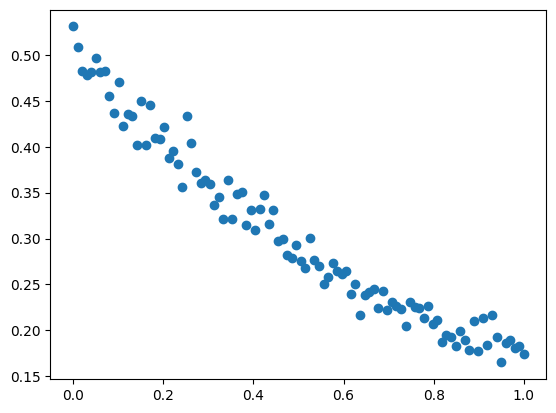

In [6]:
plt.plot(alphas, p_err, 'o')